In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# !pip install pandas numpy scipy scikit-learn interpret xgboost lightgbm matplotlib seaborn openpyxl

In [ ]:
# 1. Install packages
# pip install pandas numpy scipy scikit-learn interpret xgboost lightgbm matplotlib seaborn openpyxl
# ============================================================
# 0. Install required packages in Colab
# ============================================================
# !pip install interpret xgboost lightgbm openpyxl -q

# ============================================================
# 1. Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew

from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

In [ ]:
# ============================================================
# 2. Load data
# ============================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/OR_EBM/data/readiness.csv'

df = pd.read_csv(file_path)
display(df.head())

print("Original data shape:", df.shape)
print(df.columns.tolist())

,Gender,Airport,Job,Organizational_tenure,Organization_type,Airport_projects,FR1,FR2,FR3,FR4,...,PS11,PS12,PS13,PS14,Var_Oper_Readiness,Var_Project_Success,Fac_Facility_Readiness,Fac_People_Readiness,Fac_Tech_redainess,Fac_Organiz_Readiness
0,2,2,4,3,5,4,5,4,5,4,...,4,5,5,4,227,61,32,33,66,96
1,2,2,4,4,5,6,5,4,4,5,...,5,5,5,5,252,60,32,39,69,112
2,2,2,4,3,5,4,5,5,5,5,...,5,5,4,4,264,61,35,40,71,118
3,1,2,3,3,7,3,5,4,4,4,...,5,4,4,5,220,58,29,36,59,96
4,2,2,3,3,2,1,5,4,4,5,...,4,4,5,5,230,64,31,34,65,100


Original data shape: (633, 80)
['Gender', 'Airport', 'Job', 'Organizational_tenure', 'Organization_type', 'Airport_projects', 'FR1', 'FR2', 'FR3', 'FR4', 'FR5', 'FR6', 'FR7', 'PR1', 'PR2', 'PR3', 'PR4', 'PR5', 'PR6', 'PR7', 'PR8', 'TR1', 'TR2', 'TR3', 'TR4', 'TR5', 'TR6', 'TR7', 'TR8', 'TR9', 'TR10', 'TR11', 'TR12', 'TR13', 'TR14', 'TR15', 'OR1', 'OR2', 'OR3', 'OR4', 'OR5', 'OR6', 'OR7', 'OR8', 'OR9', 'OR10', 'OR11', 'OR12', 'OR13', 'OR14', 'OR15', 'OR16', 'OR17', 'OR18', 'OR19', 'OR20', 'OR21', 'OR22', 'OR23', 'OR24', 'PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'PS7', 'PS8', 'PS9', 'PS10', 'PS11', 'PS12', 'PS13', 'PS14', 'Var_Oper_Readiness', 'Var_Project_Success', 'Fac_Facility_Readiness', 'Fac_People_Readiness', 'Fac_Tech_redainess', 'Fac_Organiz_Readiness']


In [ ]:
# ============================================================
# 3. Define variables
# ============================================================

target = "Var_Project_Success"

main_predictors = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",      
    "Fac_Organiz_Readiness"
]

controls = [
    "Gender",
    "Airport",
    "Job",
    "Organizational_tenure",
    "Organization_type",
    "Airport_projects"
]

features = main_predictors + controls

In [ ]:
# ============================================================
# 4. Data screening
# ============================================================

print("Missing values:")
display(df[features + [target]].isna().sum())

print("Duplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=features + [target])

print("Final sample after cleaning:", df_clean.shape)

display(df_clean[features + [target]].describe())

Missing values:


,0
Fac_Facility_Readiness,0
Fac_People_Readiness,0
Fac_Tech_redainess,0
Fac_Organiz_Readiness,0
Gender,0
Airport,0
Job,0
Organizational_tenure,0
Organization_type,0
Airport_projects,0


Duplicate rows: 0
Final sample after cleaning: (633, 80)


,Fac_Facility_Readiness,Fac_People_Readiness,Fac_Tech_redainess,Fac_Organiz_Readiness,Gender,Airport,Job,Organizational_tenure,Organization_type,Airport_projects,Var_Project_Success
count,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000
mean,29.638231,34.069510,63.145340,99.816746,1.879937,2.058452,3.086888,3.646130,3.556082,3.707741,54.102686
std,4.378485,5.425698,10.144418,16.284493,0.330121,0.768071,0.795777,1.111457,2.106447,2.000369,9.073393
min,7.000000,8.000000,24.000000,33.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14.000000
25%,28.000000,32.000000,60.000000,94.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,45.000000
50%,30.000000,35.000000,65.000000,102.000000,2.000000,2.000000,3.000000,4.000000,3.000000,3.000000,55.000000
75%,33.000000,38.000000,72.000000,114.000000,2.000000,2.000000,4.000000,5.000000,6.000000,6.000000,61.000000
max,35.000000,40.000000,75.000000,120.000000,3.000000,4.000000,4.000000,5.000000,7.000000,6.000000,70.000000


In [ ]:
# ============================================================
# 5. Descriptive statistics for main variables
# ============================================================

desc_vars = main_predictors + [target]

desc = df_clean[desc_vars].agg(["mean", "std", "min", "max"]).T
desc["skewness"] = df_clean[desc_vars].apply(lambda x: skew(x, nan_policy="omit"))

display(desc)

corr = df_clean[desc_vars].corr()
display(corr)

,mean,std,min,max,skewness
Fac_Facility_Readiness,29.638231,4.378485,7.0,35.0,-1.102866
Fac_People_Readiness,34.069510,5.425698,8.0,40.0,-1.162186
Fac_Tech_redainess,63.145340,10.144418,24.0,75.0,-0.776340
Fac_Organiz_Readiness,99.816746,16.284493,33.0,120.0,-0.652760
Var_Project_Success,54.102686,9.073393,14.0,70.0,-0.134936


,Fac_Facility_Readiness,Fac_People_Readiness,Fac_Tech_redainess,Fac_Organiz_Readiness,Var_Project_Success
Fac_Facility_Readiness,1.000000,0.720788,0.687394,0.650054,0.487954
Fac_People_Readiness,0.720788,1.000000,0.841974,0.763268,0.558592
Fac_Tech_redainess,0.687394,0.841974,1.000000,0.884684,0.646695
Fac_Organiz_Readiness,0.650054,0.763268,0.884684,1.000000,0.692973
Var_Project_Success,0.487954,0.558592,0.646695,0.692973,1.000000


In [ ]:
# ============================================================
# 6. Prepare X and y
# ============================================================

X = df_clean[features]
y = df_clean[target]

numeric_features = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness",
    "Organizational_tenure",
    "Airport_projects"
]

categorical_features = [
    "Gender",
    "Airport",
    "Job",
    "Organization_type"
]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [ ]:
# ============================================================
# 7. Benchmark models: Linear, Ridge, LASSO, RF, XGBoost, LightGBM, EBM
# ============================================================
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": RidgeCV(),

    "LASSO": LassoCV(
        max_iter=10000,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost_GPU": XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device=device,
        random_state=42
    ),

    "LightGBM_GPU": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        device=device,
        random_state=42
    ),

    "EBM": ExplainableBoostingRegressor(
        interactions=10,
        random_state=42,
        n_jobs=-1
    )
}

# cv = RepeatedKFold(
#     n_splits=5,
#     n_repeats=3,
#     random_state=42
# )

cv = RepeatedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score),
    "MAPE": make_scorer(mean_absolute_percentage_error, greater_is_better=False)
}

results = []

n = X.shape[0]
p = X.shape[1]

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    mean_r2 = scores["test_R2"].mean()
    adjusted_r2 = 1 - ((1 - mean_r2) * (n - 1) / (n - p - 1))

    results.append({
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": mean_r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": -scores["test_MAPE"].mean()
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

Using device: cpu


AttributeError: 'torch.device' object has no attribute 'startswith'

In [ ]:
# ============================================================
# 8. Main OR_EBM model with readiness dimensions only
# Cleaner for nonlinear curves and threshold interpretation
# ============================================================

X_main = df_clean[main_predictors]
y = df_clean[target]

ebm_main = ExplainableBoostingRegressor(
    interactions=10,
    random_state=42
)

ebm_main.fit(X_main, y)

show(ebm_main.explain_global())

In [ ]:
# ============================================================
# 9. OR_EBM model with controls
# Use this as robustness / full model
# ============================================================

ebm_full_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", ExplainableBoostingRegressor(
        interactions=10,
        random_state=42
    ))
])

ebm_full_pipe.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Fac_Facility_Readiness',
                                                   'Fac_People_Readiness',
                                                   'Fac_Tech_redainess',
                                                   'Fac_Organiz_Readiness',
                                                   'Organizational_tenure',
                                                   'Airport_projects']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Airport', 'Job',
                                                   'Organization_type'])])),
                ('model', ExplainableBoostingRegressor(interactions=10))])

In [ ]:
# ============================================================
# 10. Feature importance from main OR_EBM
# ============================================================

global_exp = ebm_main.explain_global()
importance_df = pd.DataFrame({
    "Feature": global_exp.data()["names"],
    "Importance": global_exp.data()["scores"]
}).sort_values("Importance", ascending=False)

display(importance_df)

,Feature,Importance
3,Fac_Organiz_Readiness,3.092014
2,Fac_Tech_redainess,1.374601
0,Fac_Facility_Readiness,0.607197
1,Fac_People_Readiness,0.437719
9,Fac_Tech_redainess & Fac_Organiz_Readiness,0.174895
6,Fac_Facility_Readiness & Fac_Organiz_Readiness,0.132697
8,Fac_People_Readiness & Fac_Organiz_Readiness,0.108442
7,Fac_People_Readiness & Fac_Tech_redainess,0.101280
5,Fac_Facility_Readiness & Fac_Tech_redainess,0.100801
4,Fac_Facility_Readiness & Fac_People_Readiness,0.077923


In [ ]:
importance_df

,Feature,Importance
3,Fac_Organiz_Readiness,3.092014
2,Fac_Tech_redainess,1.374601
0,Fac_Facility_Readiness,0.607197
1,Fac_People_Readiness,0.437719
9,Fac_Tech_redainess & Fac_Organiz_Readiness,0.174895
6,Fac_Facility_Readiness & Fac_Organiz_Readiness,0.132697
8,Fac_People_Readiness & Fac_Organiz_Readiness,0.108442
7,Fac_People_Readiness & Fac_Tech_redainess,0.101280
5,Fac_Facility_Readiness & Fac_Tech_redainess,0.100801
4,Fac_Facility_Readiness & Fac_People_Readiness,0.077923


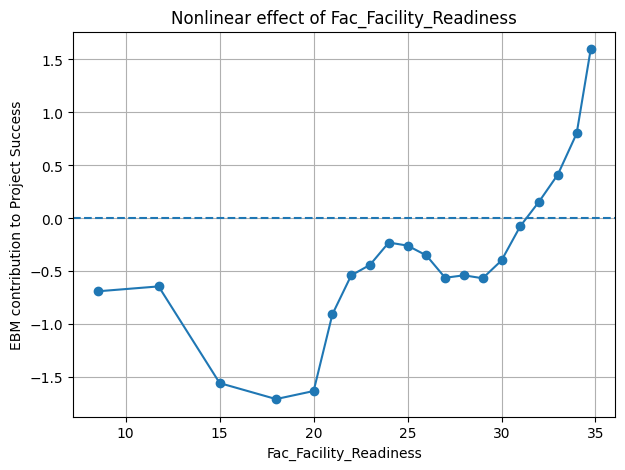

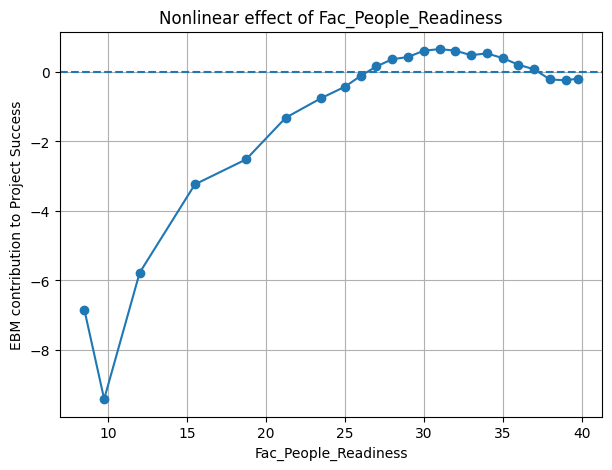

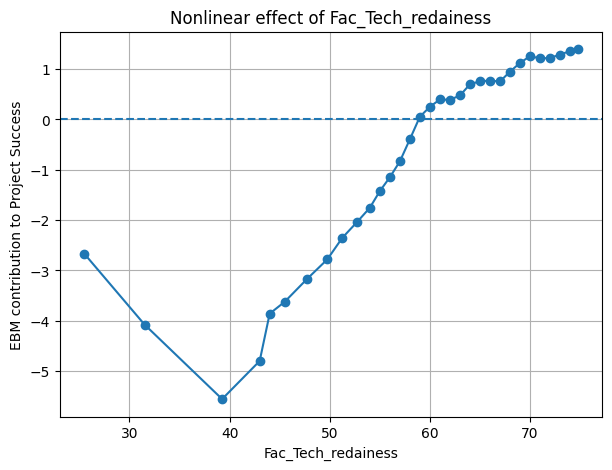

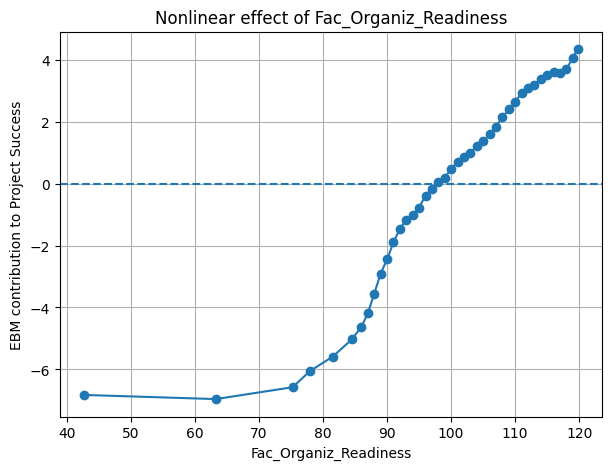

In [ ]:
# ============================================================
# 11. Plot nonlinear effect curves manually
# ============================================================

global_exp = ebm_main.explain_global()

for i, feature in enumerate(main_predictors):
    data = global_exp.data(i)

    x = np.array(data["names"])
    y_scores = np.array(data["scores"])

    # If x has one more value than scores, use bin midpoints
    if len(x) == len(y_scores) + 1:
        x_plot = (x[:-1] + x[1:]) / 2
    else:
        x_plot = x[:len(y_scores)]

    plt.figure(figsize=(7, 5))
    plt.plot(x_plot, y_scores, marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("EBM contribution to Project Success")
    plt.title(f"Nonlinear effect of {feature}")
    plt.grid(True)
    plt.show()

In [ ]:
# ============================================================
# 12. Item-level OR_EBM models
# Separate models for FR, PR, TR, OR items
# ============================================================

item_groups = {
    "Facilities_Readiness": [f"FR{i}" for i in range(1, 8)],
    "People_Readiness": [f"PR{i}" for i in range(1, 9)],
    "Technology_Readiness": [f"TR{i}" for i in range(1, 16)],
    "Organisation_Readiness": [f"OR{i}" for i in range(1, 25)]
}

item_importance_results = []

for dimension, items in item_groups.items():
    available_items = [col for col in items if col in df_clean.columns]

    X_items = df_clean[available_items]
    y = df_clean[target]

    item_ebm = ExplainableBoostingRegressor(
        interactions=5,
        random_state=42
    )

    item_ebm.fit(X_items, y)

    exp = item_ebm.explain_global()

    temp = pd.DataFrame({
        "Dimension": dimension,
        "Item": exp.data()["names"],
        "Importance": exp.data()["scores"]
    }).sort_values("Importance", ascending=False)

    item_importance_results.append(temp)

item_importance_df = pd.concat(item_importance_results)
display(item_importance_df)

,Dimension,Item,Importance
0,Facilities_Readiness,FR1,0.721203
5,Facilities_Readiness,FR6,0.708315
1,Facilities_Readiness,FR2,0.707853
6,Facilities_Readiness,FR7,0.656175
4,Facilities_Readiness,FR5,0.636852
...,...,...,...
23,Organisation_Readiness,OR24,0.185227
11,Organisation_Readiness,OR12,0.184891
13,Organisation_Readiness,OR14,0.171563
5,Organisation_Readiness,OR6,0.164139


In [ ]:
# ============================================================
# 13. Top item from each dimension
# ============================================================

top_items = item_importance_df.groupby("Dimension").head(1)
display(top_items)

,Dimension,Item,Importance
0,Facilities_Readiness,FR1,0.721203
6,People_Readiness,PR7,0.787183
8,Technology_Readiness,TR9,0.701562
19,Organisation_Readiness,OR20,0.375667


#### State-of-the-art implementation

In [ ]:
# ============================================================
# 0. Install packages
# ============================================================
!!pip install interpret xgboost lightgbm tensorflow openpyxl -q

In [ ]:
# ============================================================
# 1. Import libraries
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew

from sklearn.model_selection import RepeatedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# ============================================================
# 2. Check GPU
# ============================================================
gpu_available = len(tf.config.list_physical_devices("GPU")) > 0

print("GPU available:", gpu_available)

if gpu_available:
    !nvidia-smi

GPU available: True
Mon Jun 22 06:44:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
# ============================================================
# 3. Load data
# ============================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/OR_EBM/data/Readiness.csv'

df = pd.read_csv(file_path)

print("Original data shape:", df.shape)
display(df.head())

Original data shape: (633, 80)


,Gender,Airport,Job,Organizational_tenure,Organization_type,Airport_projects,FR1,FR2,FR3,FR4,...,PS11,PS12,PS13,PS14,Var_Oper_Readiness,Var_Project_Success,Fac_Facility_Readiness,Fac_People_Readiness,Fac_Tech_redainess,Fac_Organiz_Readiness
0,2,2,4,3,5,4,5,4,5,4,...,4,5,5,4,227,61,32,33,66,96
1,2,2,4,4,5,6,5,4,4,5,...,5,5,5,5,252,60,32,39,69,112
2,2,2,4,3,5,4,5,5,5,5,...,5,5,4,4,264,61,35,40,71,118
3,1,2,3,3,7,3,5,4,4,4,...,5,4,4,5,220,58,29,36,59,96
4,2,2,3,3,2,1,5,4,4,5,...,4,4,5,5,230,64,31,34,65,100


In [ ]:
# ============================================================
# 4. Define variables
# ============================================================

target = "Var_Project_Success"

main_predictors = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",      
    "Fac_Organiz_Readiness"
]

controls = [
    "Gender",
    "Airport",
    "Job",
    "Organizational_tenure",
    "Organization_type",
    "Airport_projects"
]

features = main_predictors + controls

item_groups = {
    "Facilities_Readiness": [f"FR{i}" for i in range(1, 8)],
    "People_Readiness": [f"PR{i}" for i in range(1, 9)],
    "Technology_Readiness": [f"TR{i}" for i in range(1, 16)],
    "Organisation_Readiness": [f"OR{i}" for i in range(1, 25)]
}

In [ ]:
# ============================================================
# 5. Data screening
# ============================================================

print("Missing values:")
display(df[features + [target]].isna().sum())

print("Duplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=features + [target])

print("Final sample after cleaning:", df_clean.shape)

screening_summary = pd.DataFrame({
    "Original_rows": [df.shape[0]],
    "Original_columns": [df.shape[1]],
    "Duplicate_rows": [df.duplicated().sum()],
    "Final_rows": [df_clean.shape[0]],
    "Final_columns": [df_clean.shape[1]]
})

display(screening_summary)

Missing values:


,0
Fac_Facility_Readiness,0
Fac_People_Readiness,0
Fac_Tech_redainess,0
Fac_Organiz_Readiness,0
Gender,0
Airport,0
Job,0
Organizational_tenure,0
Organization_type,0
Airport_projects,0


Duplicate rows: 0
Final sample after cleaning: (633, 80)


,Original_rows,Original_columns,Duplicate_rows,Final_rows,Final_columns
0,633,80,0,633,80


In [ ]:
# ============================================================
# 6. Descriptive statistics and correlations
# ============================================================

desc_vars = main_predictors + [target]

descriptive_stats = df_clean[desc_vars].agg(["mean", "std", "min", "max"]).T
descriptive_stats["skewness"] = df_clean[desc_vars].apply(lambda x: skew(x, nan_policy="omit"))

correlation_matrix = df_clean[desc_vars].corr()

print("Descriptive statistics:")
display(descriptive_stats)

print("Correlation matrix:")
display(correlation_matrix)

Descriptive statistics:


,mean,std,min,max,skewness
Fac_Facility_Readiness,29.638231,4.378485,7.0,35.0,-1.102866
Fac_People_Readiness,34.069510,5.425698,8.0,40.0,-1.162186
Fac_Tech_redainess,63.145340,10.144418,24.0,75.0,-0.776340
Fac_Organiz_Readiness,99.816746,16.284493,33.0,120.0,-0.652760
Var_Project_Success,54.102686,9.073393,14.0,70.0,-0.134936


Correlation matrix:


,Fac_Facility_Readiness,Fac_People_Readiness,Fac_Tech_redainess,Fac_Organiz_Readiness,Var_Project_Success
Fac_Facility_Readiness,1.000000,0.720788,0.687394,0.650054,0.487954
Fac_People_Readiness,0.720788,1.000000,0.841974,0.763268,0.558592
Fac_Tech_redainess,0.687394,0.841974,1.000000,0.884684,0.646695
Fac_Organiz_Readiness,0.650054,0.763268,0.884684,1.000000,0.692973
Var_Project_Success,0.487954,0.558592,0.646695,0.692973,1.000000


In [ ]:
# ============================================================
# 7. Prepare modelling data
# ============================================================

X = df_clean[features]
y = df_clean[target]

numeric_features = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness",
    "Organizational_tenure",
    "Airport_projects"
]

categorical_features = [
    "Gender",
    "Airport",
    "Job",
    "Organization_type"
]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [ ]:
# ============================================================
# 8. Metric function
# ============================================================

def calculate_metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    n = len(y_true)
    if n - n_features - 1 > 0:
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    else:
        adj_r2 = np.nan

    accuracy_percent = (1 - mape) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "MAPE": mape,
        "Prediction_Accuracy_%": accuracy_percent
    }

In [ ]:
# ============================================================
# 9. Define benchmark models
# ============================================================

if gpu_available:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    lgbm_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        device="gpu",
        random_state=42
    )
else:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    )

    lgbm_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        random_state=42
    )

models_dict = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": RidgeCV(),

    "LASSO": LassoCV(
        max_iter=10000,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": xgb_model,

    "LightGBM": lgbm_model,

    "EBM": ExplainableBoostingRegressor(
        interactions=10,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# ============================================================
# 10. Cross-validation benchmark
# Use 5x3 for speed.
# For final paper, change to n_splits=10, n_repeats=5.
# ============================================================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

benchmark_results = []

for model_name, model in models_dict.items():
    print(f"Running: {model_name}")

    fold_results = []

    try:
        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipe = Pipeline([
                ("preprocess", preprocess),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            metrics = calculate_metrics(y_test, y_pred, n_features=len(features))
            fold_results.append(metrics)

        fold_df = pd.DataFrame(fold_results)

        benchmark_results.append({
            "Model": model_name,
            "MAE": fold_df["MAE"].mean(),
            "RMSE": fold_df["RMSE"].mean(),
            "R2": fold_df["R2"].mean(),
            "Adjusted_R2": fold_df["Adjusted_R2"].mean(),
            "MAPE": fold_df["MAPE"].mean(),
            "Prediction_Accuracy_%": fold_df["Prediction_Accuracy_%"].mean()
        })

    except Exception as e:
        print(f"{model_name} failed:", e)

        benchmark_results.append({
            "Model": model_name,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Adjusted_R2": np.nan,
            "MAPE": np.nan,
            "Prediction_Accuracy_%": np.nan
        })

benchmark_results_df = pd.DataFrame(benchmark_results).sort_values("RMSE")
display(benchmark_results_df)

In [ ]:
# ============================================================
# 11. Optional SOTA-style deep learning comparison
# ANN and Autoencoder + ANN
# This is optional. It is useful for comparison, not the main method.
# ============================================================

RUN_DEEP_MODELS = True

def build_ann(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model


def build_autoencoder(input_dim, latent_dim=8):
    input_layer = layers.Input(shape=(input_dim,))

    encoded = layers.Dense(32, activation="relu")(input_layer)
    encoded = layers.Dense(latent_dim, activation="relu", name="latent_layer")(encoded)

    decoded = layers.Dense(32, activation="relu")(encoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return autoencoder, encoder


if RUN_DEEP_MODELS:

    deep_results = []

    deep_cv = RepeatedKFold(
        n_splits=5,
        n_repeats=1,
        random_state=42
    )

    for deep_model_name in ["ANN", "Autoencoder_ANN"]:
        print(f"Running deep model: {deep_model_name}")

        fold_results = []

        for train_idx, test_idx in deep_cv.split(X):
            X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
            y_train_raw, y_test = y.iloc[train_idx], y.iloc[test_idx]

            local_preprocess = ColumnTransformer([
                ("num", StandardScaler(), numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ])

            X_train_trans = local_preprocess.fit_transform(X_train_raw)
            X_test_trans = local_preprocess.transform(X_test_raw)

            if hasattr(X_train_trans, "toarray"):
                X_train_trans = X_train_trans.toarray()
                X_test_trans = X_test_trans.toarray()

            y_mean = y_train_raw.mean()
            y_std = y_train_raw.std()

            y_train_scaled = (y_train_raw - y_mean) / y_std

            early_stop = callbacks.EarlyStopping(
                monitor="val_loss",
                patience=20,
                restore_best_weights=True
            )

            if deep_model_name == "ANN":
                ann = build_ann(X_train_trans.shape[1])

                ann.fit(
                    X_train_trans,
                    y_train_scaled,
                    validation_split=0.2,
                    epochs=300,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0
                )

                y_pred_scaled = ann.predict(X_test_trans, verbose=0).flatten()
                y_pred = y_pred_scaled * y_std + y_mean

            else:
                autoencoder, encoder = build_autoencoder(
                    input_dim=X_train_trans.shape[1],
                    latent_dim=min(8, X_train_trans.shape[1])
                )

                autoencoder.fit(
                    X_train_trans,
                    X_train_trans,
                    validation_split=0.2,
                    epochs=300,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0
                )

                X_train_encoded = encoder.predict(X_train_trans, verbose=0)
                X_test_encoded = encoder.predict(X_test_trans, verbose=0)

                ann = build_ann(X_train_encoded.shape[1])

                ann.fit(
                    X_train_encoded,
                    y_train_scaled,
                    validation_split=0.2,
                    epochs=300,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0
                )

                y_pred_scaled = ann.predict(X_test_encoded, verbose=0).flatten()
                y_pred = y_pred_scaled * y_std + y_mean

            metrics = calculate_metrics(y_test, y_pred, n_features=len(features))
            fold_results.append(metrics)

        fold_df = pd.DataFrame(fold_results)

        deep_results.append({
            "Model": deep_model_name,
            "MAE": fold_df["MAE"].mean(),
            "RMSE": fold_df["RMSE"].mean(),
            "R2": fold_df["R2"].mean(),
            "Adjusted_R2": fold_df["Adjusted_R2"].mean(),
            "MAPE": fold_df["MAPE"].mean(),
            "Prediction_Accuracy_%": fold_df["Prediction_Accuracy_%"].mean()
        })

    deep_results_df = pd.DataFrame(deep_results)

    final_model_comparison = pd.concat(
        [benchmark_results_df, deep_results_df],
        ignore_index=True
    ).sort_values("RMSE")

    display(final_model_comparison)

In [ ]:
# ============================================================
# 12. Main OR_EBM model using only four readiness dimensions
# This is the main glass-box model for the paper.
# ============================================================

X_main = df_clean[main_predictors]
y_main = df_clean[target]

ebm_main = ExplainableBoostingRegressor(
    interactions=10,
    random_state=42,
    n_jobs=-1
)

ebm_main.fit(X_main, y_main)

global_exp = ebm_main.explain_global()

show(global_exp)

In [ ]:
# ============================================================
# 13. Main OR_EBM feature importance
# ============================================================

importance_df = pd.DataFrame({
    "Feature": global_exp.data()["names"],
    "Importance": global_exp.data()["scores"]
}).sort_values("Importance", ascending=False)

display(importance_df)

,Feature,Importance
3,Fac_Organiz_Readiness,3.092014
2,Fac_Tech_redainess,1.374601
0,Fac_Facility_Readiness,0.607197
1,Fac_People_Readiness,0.437719
9,Fac_Tech_redainess & Fac_Organiz_Readiness,0.174895
6,Fac_Facility_Readiness & Fac_Organiz_Readiness,0.132697
8,Fac_People_Readiness & Fac_Organiz_Readiness,0.108442
7,Fac_People_Readiness & Fac_Tech_redainess,0.101280
5,Fac_Facility_Readiness & Fac_Tech_redainess,0.100801
4,Fac_Facility_Readiness & Fac_People_Readiness,0.077923


In [ ]:
# ============================================================
# 14. Separate main effects and interactions
# ============================================================

main_effects_df = importance_df[~importance_df["Feature"].str.contains("&")].copy()
interactions_df = importance_df[importance_df["Feature"].str.contains("&")].copy()

print("Main readiness effects:")
display(main_effects_df)

print("Pairwise interaction effects:")
display(interactions_df)

Main readiness effects:


,Feature,Importance
3,Fac_Organiz_Readiness,3.092014
2,Fac_Tech_redainess,1.374601
0,Fac_Facility_Readiness,0.607197
1,Fac_People_Readiness,0.437719


Pairwise interaction effects:


,Feature,Importance
9,Fac_Tech_redainess & Fac_Organiz_Readiness,0.174895
6,Fac_Facility_Readiness & Fac_Organiz_Readiness,0.132697
8,Fac_People_Readiness & Fac_Organiz_Readiness,0.108442
7,Fac_People_Readiness & Fac_Tech_redainess,0.101280
5,Fac_Facility_Readiness & Fac_Tech_redainess,0.100801
4,Fac_Facility_Readiness & Fac_People_Readiness,0.077923


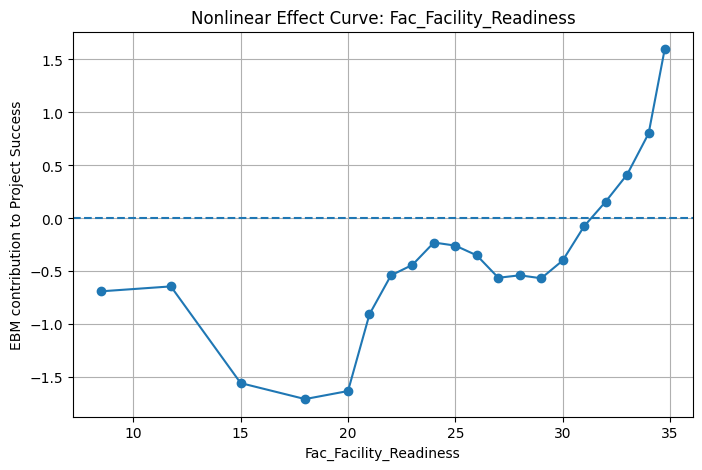

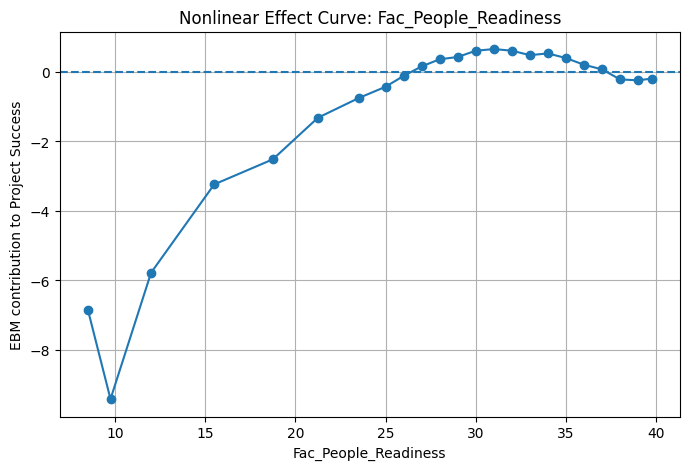

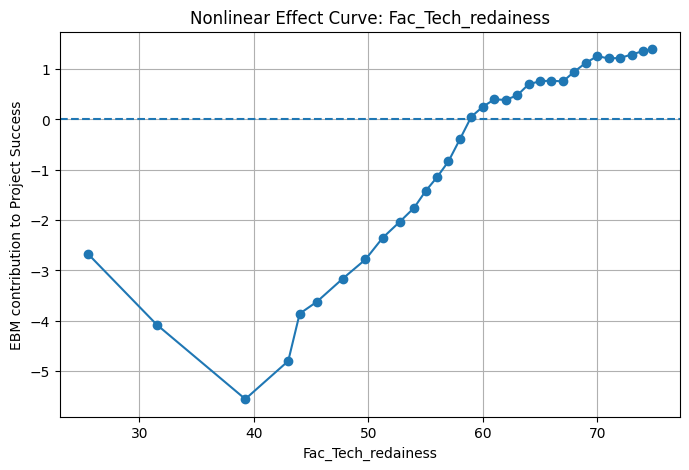

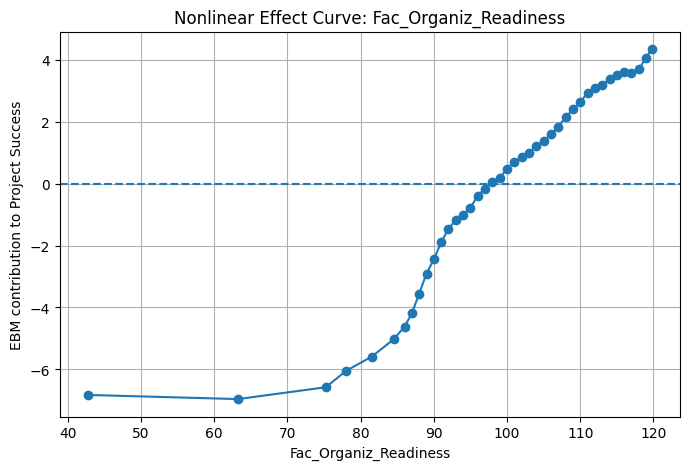

In [ ]:
# ============================================================
# 15. Plot nonlinear OR_EBM curves
# ============================================================

def get_ebm_curve_data(global_exp, feature_index):
    data = global_exp.data(feature_index)

    x = np.array(data["names"])
    scores = np.array(data["scores"])

    if len(x) == len(scores) + 1:
        x_plot = (x[:-1] + x[1:]) / 2
    else:
        x_plot = x[:len(scores)]

    return x_plot, scores


for i, feature in enumerate(main_predictors):
    x_plot, scores = get_ebm_curve_data(global_exp, i)

    plt.figure(figsize=(8, 5))
    plt.plot(x_plot, scores, marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("EBM contribution to Project Success")
    plt.title(f"Nonlinear Effect Curve: {feature}")
    plt.grid(True)
    plt.show()

In [ ]:
# ============================================================
# 16. Automatic threshold and saturation detection
# Simple rule:
# Threshold = point with largest positive jump in OR_EBM score.
# Saturation = first point after which changes become small.
# ============================================================

threshold_results = []

for i, feature in enumerate(main_predictors):
    x_plot, scores = get_ebm_curve_data(global_exp, i)

    diffs = np.diff(scores)

    if len(diffs) > 0:
        max_jump_idx = np.argmax(diffs)
        threshold_point = x_plot[max_jump_idx + 1]
        max_jump_value = diffs[max_jump_idx]

        abs_diffs = np.abs(diffs)
        small_change_cutoff = 0.10 * np.max(abs_diffs) if np.max(abs_diffs) > 0 else 0

        saturation_point = np.nan

        for j in range(len(abs_diffs)):
            remaining_changes = abs_diffs[j:]
            if len(remaining_changes) >= 3 and np.all(remaining_changes[:3] <= small_change_cutoff):
                saturation_point = x_plot[j + 1]
                break

        threshold_results.append({
            "Feature": feature,
            "Estimated_Threshold_Point": threshold_point,
            "Largest_Positive_Jump": max_jump_value,
            "Estimated_Saturation_Point": saturation_point
        })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

In [ ]:
# ============================================================
# 17. Item-level OR_EBM analysis
# Separate models for FR, PR, TR, and OR items
# ============================================================

item_importance_results = []

for dimension, items in item_groups.items():
    available_items = [col for col in items if col in df_clean.columns]

    X_items = df_clean[available_items]
    y_items = df_clean[target]

    item_ebm = ExplainableBoostingRegressor(
        interactions=5,
        random_state=42,
        n_jobs=-1
    )

    item_ebm.fit(X_items, y_items)

    item_exp = item_ebm.explain_global()

    temp = pd.DataFrame({
        "Dimension": dimension,
        "Item": item_exp.data()["names"],
        "Importance": item_exp.data()["scores"]
    }).sort_values("Importance", ascending=False)

    item_importance_results.append(temp)

item_importance_df = pd.concat(item_importance_results, ignore_index=True)

display(item_importance_df)

,Dimension,Item,Importance
0,Facilities_Readiness,FR1,0.721203
1,Facilities_Readiness,FR6,0.708315
2,Facilities_Readiness,FR2,0.707853
3,Facilities_Readiness,FR7,0.656175
4,Facilities_Readiness,FR5,0.636852
...,...,...,...
69,Organisation_Readiness,OR24,0.185227
70,Organisation_Readiness,OR12,0.184891
71,Organisation_Readiness,OR14,0.171563
72,Organisation_Readiness,OR6,0.164139


In [ ]:
# ============================================================
# 18. Top main item from each readiness dimension
# Excludes interaction terms using "&"
# ============================================================

item_main_only = item_importance_df[
    ~item_importance_df["Item"].str.contains("&")
].copy()

top_items_each_dimension = (
    item_main_only
    .sort_values(["Dimension", "Importance"], ascending=[True, False])
    .groupby("Dimension")
    .head(1)
)

display(top_items_each_dimension)

,Dimension,Item,Importance
0,Facilities_Readiness,FR1,0.721203
45,Organisation_Readiness,OR20,0.375667
12,People_Readiness,PR7,0.787183
25,Technology_Readiness,TR9,0.701562


In [ ]:
# ============================================================
# 19. Export all results to Excel
# ============================================================

output_path = "/content/ORAT_EBM_ML_Results.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    screening_summary.to_excel(writer, sheet_name="Data_Screening", index=False)
    descriptive_stats.to_excel(writer, sheet_name="Descriptive_Stats")
    correlation_matrix.to_excel(writer, sheet_name="Correlations")
    benchmark_results_df.to_excel(writer, sheet_name="Benchmark_Models", index=False)

    if RUN_DEEP_MODELS:
        final_model_comparison.to_excel(writer, sheet_name="Final_Model_Comparison", index=False)

    importance_df.to_excel(writer, sheet_name="EBM_Importance", index=False)
    main_effects_df.to_excel(writer, sheet_name="Main_Effects", index=False)
    interactions_df.to_excel(writer, sheet_name="Interactions", index=False)
    threshold_results_df.to_excel(writer, sheet_name="Thresholds", index=False)
    item_importance_df.to_excel(writer, sheet_name="Item_Level_EBM", index=False)
    top_items_each_dimension.to_excel(writer, sheet_name="Top_Items", index=False)

print("Results exported to:", output_path)

In [ ]:
display(final_model_comparison)
display(importance_df)
display(threshold_results_df)
display(top_items_each_dimension)

**SOTA** 2

In [ ]:
# ============================================================
# 3. Define variables
# ============================================================

target = "Var_Project_Success"

main_predictors = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness"
]

controls = [
    "Gender",
    "Airport",
    "Job",
    "Organizational_tenure",
    "Organization_type",
    "Airport_projects"
]

features = main_predictors + controls

df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=features + [target])

print("Final sample:", df_clean.shape)

X = df_clean[features]
y = df_clean[target]

Final sample: (633, 80)


In [ ]:
# ============================================================
# 4. Preprocessing
# ============================================================

numeric_features = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness",
    "Organizational_tenure",
    "Airport_projects"
]

categorical_features = [
    "Gender",
    "Airport",
    "Job",
    "Organization_type"
]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

In [ ]:
# ============================================================
# 5. Metric function
# ============================================================

def calculate_metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    prediction_accuracy = (1 - mape) * 100

    n = len(y_true)
    if n - n_features - 1 > 0:
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    else:
        adjusted_r2 = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape,
        "Prediction_Accuracy_%": prediction_accuracy
    }

In [ ]:
# ============================================================
# 6. Check GPU for XGBoost
# ============================================================

def gpu_available():
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        return result.returncode == 0
    except:
        return False

USE_GPU = gpu_available()
print("GPU available:", USE_GPU)

GPU available: False


In [ ]:
# ============================================================
# 1. Import libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import subprocess

from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor
from interpret.glassbox import ExplainableBoostingRegressor

In [ ]:
# ============================================================
# 7. Define SOTA-inspired models
# ============================================================

if USE_GPU:
    xgb_regressor = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
else:
    xgb_regressor = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    )

gpr_kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

base_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

base_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

base_svr = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)

base_knn = KNeighborsRegressor(
    n_neighbors=7,
    weights="distance"
)

stacking_regressor = StackingRegressor(
    estimators=[
        ("rf", base_rf),
        ("xgb", base_xgb),
        ("svr", base_svr),
        ("knn", base_knn)
    ],
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

models_sota = {
    "MLR": LinearRegression(),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", RidgeCV())
    ]),

    "GPR": GaussianProcessRegressor(
        kernel=gpr_kernel,
        normalize_y=True,
        random_state=42
    ),

    "SVR": SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": xgb_regressor,

    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=7,
        weights="distance"
    ),

    "Stacking Ensemble Regression": stacking_regressor,

    "EBM": ExplainableBoostingRegressor(
        interactions=10,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# ============================================================
# 8. Cross-validation comparison
# This follows the SOTA logic: compare many ML regressors.
# For faster testing, use 5 folds × 3 repeats.
# For final paper, use 10 folds × 5 repeats.
# ============================================================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

sota_results = []

for model_name, model in models_sota.items():
    print(f"Running model: {model_name}")

    fold_results = []

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", model)
        ])

        final_model = TransformedTargetRegressor(
            regressor=pipe,
            transformer=StandardScaler()
        )

        final_model.fit(X_train, y_train)
        y_pred = final_model.predict(X_test)

        metrics = calculate_metrics(
            y_true=y_test,
            y_pred=y_pred,
            n_features=len(features)
        )

        fold_results.append(metrics)

    fold_df = pd.DataFrame(fold_results)

    sota_results.append({
        "Model": model_name,
        "MAE": fold_df["MAE"].mean(),
        "RMSE": fold_df["RMSE"].mean(),
        "R2": fold_df["R2"].mean(),
        "Adjusted_R2": fold_df["Adjusted_R2"].mean(),
        "MAPE": fold_df["MAPE"].mean(),
        "Prediction_Accuracy_%": fold_df["Prediction_Accuracy_%"].mean()
    })

sota_results_df = pd.DataFrame(sota_results).sort_values("RMSE")

display(sota_results_df)

In [ ]:
# ============================================================
# 9. 70:30 holdout validation
# This matches the carbon-emission paper's train-test style.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

holdout_results = []

for model_name, model in models_sota.items():
    print(f"Running holdout model: {model_name}")

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    final_model = TransformedTargetRegressor(
        regressor=pipe,
        transformer=StandardScaler()
    )

    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    metrics = calculate_metrics(
        y_true=y_test,
        y_pred=y_pred,
        n_features=len(features)
    )

    holdout_results.append({
        "Model": model_name,
        **metrics
    })

holdout_results_df = pd.DataFrame(holdout_results).sort_values("RMSE")

display(holdout_results_df)

In [ ]:
# ============================================================
# 10. Compare CV and holdout results
# ============================================================

comparison_df = sota_results_df.merge(
    holdout_results_df,
    on="Model",
    suffixes=("_CV", "_Holdout")
)

display(comparison_df)

In [ ]:
# ============================================================
# 11. Fit final Stacking Ensemble and calculate permutation importance
# This gives sensitivity-style interpretation for the SOTA benchmark.
# ============================================================

from sklearn.inspection import permutation_importance

best_stack_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", stacking_regressor)
])

best_stack_model = TransformedTargetRegressor(
    regressor=best_stack_pipe,
    transformer=StandardScaler()
)

best_stack_model.fit(X_train, y_train)

perm = permutation_importance(
    best_stack_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(permutation_importance_df)

In [ ]:
# ============================================================
# 12. Fit final OR_EBM for main glass-box interpretation
# ============================================================

X_main = df_clean[main_predictors]
y_main = df_clean[target]

ebm_main = ExplainableBoostingRegressor(
    interactions=10,
    random_state=42,
    n_jobs=-1
)

ebm_main.fit(X_main, y_main)

ebm_exp = ebm_main.explain_global()

ebm_importance_df = pd.DataFrame({
    "Feature": ebm_exp.data()["names"],
    "Importance": ebm_exp.data()["scores"]
}).sort_values("Importance", ascending=False)

display(ebm_importance_df)

In [ ]:
# ============================================================
# 13. Export all SOTA comparison results
# ============================================================

output_path = "/content/ORAT_SOTA_Model_Comparison2.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    sota_results_df.to_excel(writer, sheet_name="Repeated_CV", index=False)
    holdout_results_df.to_excel(writer, sheet_name="Holdout_70_30", index=False)
    comparison_df.to_excel(writer, sheet_name="CV_vs_Holdout", index=False)
    permutation_importance_df.to_excel(writer, sheet_name="Stacking_Sensitivity", index=False)
    ebm_importance_df.to_excel(writer, sheet_name="EBM_Importance", index=False)

print("Results exported to:", output_path)

Results exported to: /content/ORAT_SOTA_Model_Comparison2.xlsx


### SOTA 3:

In [ ]:
# ============================================================
# FSE-Enhanced Stacking Regressor
# Metrics matched with EBM results:
# MAE, RMSE, R2, Adjusted R2, MAPE, Prediction Accuracy %
# CV + Holdout
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import Lasso, Ridge, BayesianRidge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. USER CONFIGURATION
# ============================================================


target = "Var_Project_Success"

'''main_predictors = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",     
    "Fac_Organiz_Readiness"
]

controls = [
    "Gender",
    "Airport",
    "Job",
    "Organizational_tenure",
    "Organization_type",
    "Airport_projects"
]'''




DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/OR_EBM/data/Readiness.csv"       
TARGET_COL = target     
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5


EBM_RESULTS_FILE = None

# EBM_RESULTS_FILE = "EBM_results.csv"


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(float)

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]


# ============================================================
# 3. PREPROCESSING
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# ============================================================
# 4. FEATURE-SELECTION ENHANCEMENT MODULE
# ============================================================

def make_fse_selector():
    """
    Feature-selection enhancement using Lasso.
    You may replace this if your paper uses another FSE method.
    """
    selector_model = Lasso(
        alpha=0.001,
        max_iter=10000,
        random_state=RANDOM_STATE
    )

    return SelectFromModel(
        estimator=selector_model,
        threshold="median"
    )


def make_pipeline_with_fse(model):
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("fse", make_fse_selector()),
        ("model", model)
    ])


# ============================================================
# 5. METRIC FUNCTIONS
# ============================================================

def adjusted_r2_score(y_true, y_pred, n_features):
    """
    Adjusted R2 = 1 - [(1 - R2)(n - 1) / (n - p - 1)]
    """
    n = len(y_true)
    p = n_features

    r2 = r2_score(y_true, y_pred)

    if n <= p + 1:
        return np.nan

    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


def mean_absolute_percentage_error_safe(y_true, y_pred):
    """
    MAPE with protection against zero target values.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
    ) * 100


def prediction_accuracy_from_mape(mape):
    """
    Prediction Accuracy (%) = 100 - MAPE
    """
    if np.isnan(mape):
        return np.nan
    return 100 - mape


def calculate_regression_metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2_score(y_true, y_pred, n_features)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    pred_acc = prediction_accuracy_from_mape(mape)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "MAPE": mape,
        "Prediction_Accuracy_%": pred_acc
    }


# ============================================================
# 6. HYPERPARAMETER TUNING FOR BASE LEARNERS
# ============================================================

def tune_model(model, param_grid, X_train, y_train):
    cv = KFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)
    return grid.best_estimator_


def build_tuned_base_learners(X_train, y_train):
    """
    Level-1 base learners for regression:
    1. Ridge regression
    2. SVR
    3. Gradient Boosting Regressor
    4. Bayesian Ridge
    """

    # Base learner 1: Ridge Regression
    ridge_model = make_pipeline_with_fse(
        Ridge(random_state=RANDOM_STATE)
    )

    ridge_grid = {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
    }

    tuned_ridge = tune_model(ridge_model, ridge_grid, X_train, y_train)

    # Base learner 2: SVR
    svr_model = make_pipeline_with_fse(
        SVR(kernel="rbf")
    )

    svr_grid = {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
        "model__epsilon": [0.01, 0.05, 0.1]
    }

    tuned_svr = tune_model(svr_model, svr_grid, X_train, y_train)

    # Base learner 3: Gradient Boosting Regressor
    gb_model = make_pipeline_with_fse(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    )

    gb_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }

    tuned_gb = tune_model(gb_model, gb_grid, X_train, y_train)

    # Base learner 4: Bayesian Ridge
    bayes_model = make_pipeline_with_fse(
        BayesianRidge()
    )

    bayes_grid = {
        "model__alpha_1": [1e-7, 1e-6, 1e-5],
        "model__alpha_2": [1e-7, 1e-6, 1e-5],
        "model__lambda_1": [1e-7, 1e-6, 1e-5],
        "model__lambda_2": [1e-7, 1e-6, 1e-5]
    }

    tuned_bayes = tune_model(bayes_model, bayes_grid, X_train, y_train)

    return [
        ("ridge", tuned_ridge),
        ("svr", tuned_svr),
        ("gb", tuned_gb),
        ("bayesian_ridge", tuned_bayes)
    ]


# ============================================================
# 7. FSE-ENHANCED STACKING REGRESSOR
# ============================================================

def build_fse_enhanced_model(X_train, y_train):
    """
    FSE-Enhanced model:
    - Feature-selection enhancement
    - Tuned heterogeneous base learners
    - Out-of-fold stacking
    - Regularized meta-learner
    """

    base_learners = build_tuned_base_learners(X_train, y_train)

    meta_learner = Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    )

    stacking_cv = KFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    model = StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=stacking_cv,
        passthrough=False,
        n_jobs=-1
    )

    return model


# ============================================================
# 8. CV + HOLDOUT EVALUATION
# ============================================================

def evaluate_fse_enhanced_model(X, y):
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    cv = KFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    print("Building and tuning FSE-Enhanced model...")
    fse_model = build_fse_enhanced_model(X_train, y_train)

    print("Generating cross-validated predictions...")
    y_pred_cv = cross_val_predict(
        fse_model,
        X_train,
        y_train,
        cv=cv,
        n_jobs=-1
    )

    n_features = X_train.shape[1]

    cv_metrics = calculate_regression_metrics(
        y_true=y_train,
        y_pred=y_pred_cv,
        n_features=n_features
    )

    print("Fitting final FSE-Enhanced model on training data...")
    fse_model.fit(X_train, y_train)

    print("Evaluating on holdout data...")
    y_pred_holdout = fse_model.predict(X_holdout)

    holdout_metrics = calculate_regression_metrics(
        y_true=y_holdout,
        y_pred=y_pred_holdout,
        n_features=n_features
    )

    result = {
        "Model": "FSE-Enhanced"
    }

    result.update({
        "MAE_CV": cv_metrics["MAE"],
        "RMSE_CV": cv_metrics["RMSE"],
        "R2_CV": cv_metrics["R2"],
        "Adjusted_R2_CV": cv_metrics["Adjusted_R2"],
        "MAPE_CV": cv_metrics["MAPE"],
        "Prediction_Accuracy_%_CV": cv_metrics["Prediction_Accuracy_%"],

        "MAE_Holdout": holdout_metrics["MAE"],
        "RMSE_Holdout": holdout_metrics["RMSE"],
        "R2_Holdout": holdout_metrics["R2"],
        "Adjusted_R2_Holdout": holdout_metrics["Adjusted_R2"],
        "MAPE_Holdout": holdout_metrics["MAPE"],
        "Prediction_Accuracy_%_Holdout": holdout_metrics["Prediction_Accuracy_%"]
    })

    result_df = pd.DataFrame([result])

    return fse_model, result_df, y_pred_cv, y_pred_holdout, y_train, y_holdout


# ============================================================
# 9. OPTIONAL COMPARISON WITH EXISTING EBM RESULTS
# ============================================================

def combine_with_ebm_results(fse_result_df):
    """
    If you already have EBM results in a CSV file with the same columns,
    this function appends FSE-Enhanced to that table.
    """

    if EBM_RESULTS_FILE is None:
        return fse_result_df

    ebm_df = pd.read_csv(EBM_RESULTS_FILE)

    combined_df = pd.concat(
        [ebm_df, fse_result_df],
        axis=0,
        ignore_index=True
    )

    return combined_df


# ============================================================
# 10. RUN
# ============================================================

if __name__ == "__main__":

    fse_model, fse_result_df, y_pred_cv, y_pred_holdout, y_train, y_holdout = evaluate_fse_enhanced_model(X, y)

    comparison_df = combine_with_ebm_results(fse_result_df)

    # Save outputs
    fse_result_df.to_csv("FSE_Enhanced_results_only.csv", index=False)
    comparison_df.to_csv("EBM_FSE_Enhanced_comparison_results.csv", index=False)

    print("\nFSE-Enhanced Results:")
    print(fse_result_df)

    print("\nComparison Table:")
    print(comparison_df)

Building and tuning FSE-Enhanced model...
Generating cross-validated predictions...
Fitting final FSE-Enhanced model on training data...
Evaluating on holdout data...

FSE-Enhanced Results:
          Model    MAE_CV   RMSE_CV     R2_CV  Adjusted_R2_CV   MAPE_CV  \
0  FSE-Enhanced  0.001922  0.015691  0.999997        0.999996  0.007235   

   Prediction_Accuracy_%_CV  MAE_Holdout  RMSE_Holdout  R2_Holdout  \
0                 99.992765     0.000523       0.00088         1.0   

   Adjusted_R2_Holdout  MAPE_Holdout  Prediction_Accuracy_%_Holdout  
0                  1.0      0.001086                      99.998914  

Comparison Table:
          Model    MAE_CV   RMSE_CV     R2_CV  Adjusted_R2_CV   MAPE_CV  \
0  FSE-Enhanced  0.001922  0.015691  0.999997        0.999996  0.007235   

   Prediction_Accuracy_%_CV  MAE_Holdout  RMSE_Holdout  R2_Holdout  \
0                 99.992765     0.000523       0.00088         1.0   

   Adjusted_R2_Holdout  MAPE_Holdout  Prediction_Accuracy_%_Holdout

In [ ]:
# ============================================================
# DATA LEAKAGE AND RESULT SANITY CHECKS
# ============================================================

import numpy as np
import pandas as pd

print("\nDataset shape:", df.shape)
print("Target column:", TARGET_COL)

# 1. Check target distribution
print("\nTarget summary:")
print(y.describe())

print("\nTarget unique values:")
print(y.value_counts().head(20))

# 2. Check whether target column is accidentally inside X
print("\nIs target column inside X?")
print(TARGET_COL in X.columns)

# 3. Check exact duplicate rows
duplicate_rows = df.duplicated().sum()
print("\nExact duplicate rows:", duplicate_rows)

# 4. Check duplicate feature rows
duplicate_X_rows = X.duplicated().sum()
print("Duplicate feature rows:", duplicate_X_rows)

# 5. Check columns highly correlated with target
numeric_X = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).copy()

corrs = []
for col in numeric_X.columns:
    try:
        corr = np.corrcoef(numeric_X[col].fillna(numeric_X[col].median()), y)[0, 1]
        corrs.append((col, abs(corr), corr))
    except Exception:
        pass

corr_df = pd.DataFrame(corrs, columns=["Feature", "Abs_Correlation_With_Target", "Correlation"])
corr_df = corr_df.sort_values("Abs_Correlation_With_Target", ascending=False)

print("\nTop highly correlated features with target:")
print(corr_df.head(20))

# 6. Flag suspicious features
suspicious = corr_df[corr_df["Abs_Correlation_With_Target"] > 0.95]
print("\nSuspicious possible leakage features, correlation > 0.95:")
print(suspicious)

# 7. Check columns with names suggesting leakage
leak_words = [
    "success", "outcome", "result", "performance", "score", "status",
    "target", "label", "achieved", "completion", "completed"
]

possible_leak_cols = [
    col for col in X.columns
    if any(word.lower() in col.lower() for word in leak_words)
]

print("\nPossible leakage columns based on column names:")
print(possible_leak_cols)


Dataset shape: (633, 80)
Target column: Var_Project_Success

Target summary:
count    633.000000
mean      54.102686
std        9.073393
min       14.000000
25%       45.000000
50%       55.000000
75%       61.000000
max       70.000000
Name: Var_Project_Success, dtype: float64

Target unique values:
Var_Project_Success
42.0    128
56.0     61
55.0     36
70.0     35
53.0     29
61.0     25
54.0     24
60.0     21
59.0     21
52.0     21
57.0     19
50.0     18
58.0     18
49.0     15
62.0     15
64.0     14
63.0     14
65.0     14
51.0     13
66.0     13
Name: count, dtype: int64

Is target column inside X?
False

Exact duplicate rows: 0
Duplicate feature rows: 0

Top highly correlated features with target:
                  Feature  Abs_Correlation_With_Target  Correlation
73                   PS14                     0.849869     0.849869
72                   PS13                     0.834179     0.834179
71                   PS12                     0.833314     0.833314
67       

In [ ]:
# ============================================================
# FSE-Enhanced Stacking Regressor
# Corrected version using ONLY EBM predictors:
# main_predictors + controls
#
# Output metrics:
# MAE_CV, RMSE_CV, R2_CV, Adjusted_R2_CV, MAPE_CV,
# Prediction_Accuracy_%_CV,
# MAE_Holdout, RMSE_Holdout, R2_Holdout,
# Adjusted_R2_Holdout, MAPE_Holdout,
# Prediction_Accuracy_%_Holdout
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedKFold, KFold, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import Lasso, Ridge, BayesianRidge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


# ============================================================
# 1. Confirm correct modelling variables
# ============================================================

target = "Var_Project_Success"

main_predictors = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness"
]

controls = [
    "Gender",
    "Airport",
    "Job",
    "Organizational_tenure",
    "Organization_type",
    "Airport_projects"
]

features = main_predictors + controls

numeric_features = [
    "Fac_Facility_Readiness",
    "Fac_People_Readiness",
    "Fac_Tech_redainess",
    "Fac_Organiz_Readiness",
    "Organizational_tenure",
    "Airport_projects"
]

categorical_features = [
    "Gender",
    "Airport",
    "Job",
    "Organization_type"
]


# IMPORTANT:
# Use only selected predictors, not df.drop(target).
df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=features + [target])

X = df_clean[features].copy()
y = df_clean[target].astype(float).copy()

print("FSE modelling data shape:", X.shape)
print("Target shape:", y.shape)
print("Features used:", X.columns.tolist())

# Safety check: PS items must not be used as predictors
ps_leak_cols = [col for col in X.columns if col.upper().startswith("PS")]
print("PS leakage columns inside X:", ps_leak_cols)

if len(ps_leak_cols) > 0:
    raise ValueError("Leakage detected: PS columns are included in X. Remove them.")


# ============================================================
# 2. Preprocessing
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", make_onehot_encoder(), categorical_features)
])


# ============================================================
# 3. Metric function same as EBM code
# ============================================================

def calculate_metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    n = len(y_true)

    if n - n_features - 1 > 0:
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    else:
        adjusted_r2 = np.nan

    prediction_accuracy = (1 - mape) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape,
        "Prediction_Accuracy_%": prediction_accuracy
    }


# ============================================================
# 4. Feature-selection enhancement
# ============================================================

def make_fse_selector():
    """
    FSE module using LASSO-based feature selection.
    This is fitted inside each training fold to avoid leakage.
    """
    return SelectFromModel(
        estimator=Lasso(
            alpha=0.001,
            max_iter=10000,
            random_state=42
        ),
        threshold="median"
    )


def make_fse_pipeline(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("fse", make_fse_selector()),
        ("model", model)
    ])


# ============================================================
# 5. Tune base learners inside training fold
# ============================================================

def tune_model(model, param_grid, X_train, y_train):
    inner_cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)
    return grid.best_estimator_


def build_fse_enhanced_model(X_train, y_train):
    """
    FSE-Enhanced stacking regressor.

    Level 1:
    Ridge, SVR, Gradient Boosting, Bayesian Ridge

    Level 2:
    Ridge regularized meta-learner
    """

    # Base learner 1: Ridge
    ridge_pipe = make_fse_pipeline(
        Ridge(random_state=42)
    )

    ridge_grid = {
        "model__alpha": [0.01, 0.1, 1.0, 10.0]
    }

    tuned_ridge = tune_model(
        ridge_pipe,
        ridge_grid,
        X_train,
        y_train
    )

    # Base learner 2: SVR
    svr_pipe = make_fse_pipeline(
        SVR(kernel="rbf")
    )

    svr_grid = {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto", 0.01],
        "model__epsilon": [0.01, 0.05, 0.1]
    }

    tuned_svr = tune_model(
        svr_pipe,
        svr_grid,
        X_train,
        y_train
    )

    # Base learner 3: Gradient Boosting
    gb_pipe = make_fse_pipeline(
        GradientBoostingRegressor(random_state=42)
    )

    gb_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3]
    }

    tuned_gb = tune_model(
        gb_pipe,
        gb_grid,
        X_train,
        y_train
    )

    # Base learner 4: Bayesian Ridge
    bayes_pipe = make_fse_pipeline(
        BayesianRidge()
    )

    bayes_grid = {
        "model__alpha_1": [1e-7, 1e-6],
        "model__alpha_2": [1e-7, 1e-6],
        "model__lambda_1": [1e-7, 1e-6],
        "model__lambda_2": [1e-7, 1e-6]
    }

    tuned_bayes = tune_model(
        bayes_pipe,
        bayes_grid,
        X_train,
        y_train
    )

    base_learners = [
        ("ridge", tuned_ridge),
        ("svr", tuned_svr),
        ("gb", tuned_gb),
        ("bayesian_ridge", tuned_bayes)
    ]

    meta_learner = Ridge(
        alpha=1.0,
        random_state=42
    )

    stacking_cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fse_model = StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=stacking_cv,
        passthrough=False,
        n_jobs=-1
    )

    return fse_model


# ============================================================
# 6. Cross-validation evaluation
# ============================================================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

cv_fold_results = []

print("\nRunning FSE-Enhanced cross-validation...")

for fold_id, (train_idx, test_idx) in enumerate(cv.split(X), start=1):

    print(f"Running CV fold {fold_id}")

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model_cv = build_fse_enhanced_model(X_train_cv, y_train_cv)

    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_cv = model_cv.predict(X_test_cv)

    metrics_cv = calculate_metrics(
        y_true=y_test_cv,
        y_pred=y_pred_cv,
        n_features=len(features)
    )

    cv_fold_results.append(metrics_cv)

cv_fold_df = pd.DataFrame(cv_fold_results)

cv_summary = {
    "MAE_CV": cv_fold_df["MAE"].mean(),
    "RMSE_CV": cv_fold_df["RMSE"].mean(),
    "R2_CV": cv_fold_df["R2"].mean(),
    "Adjusted_R2_CV": cv_fold_df["Adjusted_R2"].mean(),
    "MAPE_CV": cv_fold_df["MAPE"].mean(),
    "Prediction_Accuracy_%_CV": cv_fold_df["Prediction_Accuracy_%"].mean()
}


# ============================================================
# 7. Holdout evaluation
# ============================================================

print("\nRunning FSE-Enhanced holdout validation...")

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

final_fse_model = build_fse_enhanced_model(X_train, y_train)

final_fse_model.fit(X_train, y_train)

y_pred_holdout = final_fse_model.predict(X_holdout)

holdout_metrics = calculate_metrics(
    y_true=y_holdout,
    y_pred=y_pred_holdout,
    n_features=len(features)
)

holdout_summary = {
    "MAE_Holdout": holdout_metrics["MAE"],
    "RMSE_Holdout": holdout_metrics["RMSE"],
    "R2_Holdout": holdout_metrics["R2"],
    "Adjusted_R2_Holdout": holdout_metrics["Adjusted_R2"],
    "MAPE_Holdout": holdout_metrics["MAPE"],
    "Prediction_Accuracy_%_Holdout": holdout_metrics["Prediction_Accuracy_%"]
}


# ============================================================
# 8. Final FSE result table
# ============================================================

fse_result = {
    "Model": "FSE-Enhanced",
    **cv_summary,
    **holdout_summary
}

fse_result_df = pd.DataFrame([fse_result])

display(fse_result_df)

fse_result_df.to_excel("FSE_Enhanced_Only_Result.xlsx", index=False)
fse_result_df.to_csv("FSE_Enhanced_Only_Result.csv", index=False)

print("\nSaved:")
print("FSE_Enhanced_Only_Result.xlsx")
print("FSE_Enhanced_Only_Result.csv")


# ============================================================
# 9. Optional: add FSE result to your existing model comparison table
# ============================================================

if "comparison_df" in globals():
    comparison_with_fse = pd.concat(
        [comparison_df, fse_result_df],
        ignore_index=True
    ).sort_values("RMSE_CV")

    display(comparison_with_fse)

    comparison_with_fse.to_excel(
        "Model_Comparison_With_FSE_Enhanced.xlsx",
        index=False
    )

    print("Saved: Model_Comparison_With_FSE_Enhanced.xlsx")

elif "final_model_comparison" in globals():
    temp_comparison = final_model_comparison.copy()

    # If your existing table has unsuffixed columns, this block will not merge directly.
    # Use only if final_model_comparison already has CV/Holdout suffixes.
    try:
        comparison_with_fse = pd.concat(
            [temp_comparison, fse_result_df],
            ignore_index=True
        )

        display(comparison_with_fse)

        comparison_with_fse.to_excel(
            "Model_Comparison_With_FSE_Enhanced.xlsx",
            index=False
        )

        print("Saved: Model_Comparison_With_FSE_Enhanced.xlsx")

    except Exception as e:
        print("Could not append to final_model_comparison:", e)

In [ ]:
# ============================================================
# Clean comparison table: remove old leaked FSE result
# ============================================================

# Keep only benchmark/comparator models, remove any previous FSE rows
if "comparison_df" in globals():
    base_comparison = comparison_df.copy()
elif "final_model_comparison" in globals():
    base_comparison = final_model_comparison.copy()
else:
    base_comparison = pd.DataFrame()

# Remove any old FSE-Enhanced rows
if not base_comparison.empty and "Model" in base_comparison.columns:
    base_comparison = base_comparison[
        base_comparison["Model"] != "FSE-Enhanced"
    ].copy()

# Add only the corrected FSE result
comparison_with_fse_clean = pd.concat(
    [base_comparison, fse_result_df],
    ignore_index=True
)

# Sort using RMSE_CV if available
if "RMSE_CV" in comparison_with_fse_clean.columns:
    comparison_with_fse_clean = comparison_with_fse_clean.sort_values("RMSE_CV")

display(comparison_with_fse_clean)

comparison_with_fse_clean.to_excel(
    "Clean_Model_Comparison_With_Corrected_FSE.xlsx",
    index=False
)

comparison_with_fse_clean.to_csv(
    "Clean_Model_Comparison_With_Corrected_FSE.csv",
    index=False
)

print("Saved clean comparison table.")

In [ ]:
# ============================================================
# 8. Main FSE-Enhanced model with readiness dimensions only
# Permutation importance replaces OR_EBM explain_global()
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import Lasso, Ridge, BayesianRidge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocess_for_X(X_local):
    numeric_cols = X_local.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols = [
        col for col in X_local.columns
        if col not in numeric_cols
    ]

    preprocess_local = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", make_onehot_encoder(), categorical_cols)
    ])

    return preprocess_local


def make_fse_selector():
    return SelectFromModel(
        estimator=Lasso(
            alpha=0.001,
            max_iter=10000,
            random_state=RANDOM_STATE
        ),
        threshold="median"
    )


def make_fse_pipeline(model, X_local):
    preprocess_local = make_preprocess_for_X(X_local)

    return Pipeline([
        ("preprocess", preprocess_local),
        ("fse", make_fse_selector()),
        ("model", model)
    ])


def tune_model(model, param_grid, X_train, y_train):
    inner_cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)
    return grid.best_estimator_


def build_fse_enhanced_model(X_train, y_train):
    """
    FSE-Enhanced stacking regressor.

    Level 1:
    Ridge, SVR, Gradient Boosting, Bayesian Ridge

    Level 2:
    Ridge regularized meta-learner
    """

    ridge_pipe = make_fse_pipeline(
        Ridge(random_state=RANDOM_STATE),
        X_train
    )

    tuned_ridge = tune_model(
        ridge_pipe,
        {"model__alpha": [0.01, 0.1, 1.0, 10.0]},
        X_train,
        y_train
    )

    svr_pipe = make_fse_pipeline(
        SVR(kernel="rbf"),
        X_train
    )

    tuned_svr = tune_model(
        svr_pipe,
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto", 0.01],
            "model__epsilon": [0.01, 0.05, 0.1]
        },
        X_train,
        y_train
    )

    gb_pipe = make_fse_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        X_train
    )

    tuned_gb = tune_model(
        gb_pipe,
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3]
        },
        X_train,
        y_train
    )

    bayes_pipe = make_fse_pipeline(
        BayesianRidge(),
        X_train
    )

    tuned_bayes = tune_model(
        bayes_pipe,
        {
            "model__alpha_1": [1e-7, 1e-6],
            "model__alpha_2": [1e-7, 1e-6],
            "model__lambda_1": [1e-7, 1e-6],
            "model__lambda_2": [1e-7, 1e-6]
        },
        X_train,
        y_train
    )

    base_learners = [
        ("ridge", tuned_ridge),
        ("svr", tuned_svr),
        ("gb", tuned_gb),
        ("bayesian_ridge", tuned_bayes)
    ]

    meta_learner = Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    )

    stacking_cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    fse_model = StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=stacking_cv,
        passthrough=False,
        n_jobs=-1
    )

    return fse_model


def get_fse_permutation_importance(model, X_data, y_data, feature_names):
    perm = permutation_importance(
        model,
        X_data,
        y_data,
        n_repeats=30,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": perm.importances_mean,
        "Importance_SD": perm.importances_std
    }).sort_values("Importance", ascending=False)

    return importance_df


# Main readiness-only FSE model
X_main = df_clean[main_predictors].copy()
y = df_clean[target].astype(float).copy()

print("Fitting main FSE-Enhanced model using readiness dimensions only...")

fse_main = build_fse_enhanced_model(X_main, y)
fse_main.fit(X_main, y)

fse_main_importance_df = get_fse_permutation_importance(
    model=fse_main,
    X_data=X_main,
    y_data=y,
    feature_names=X_main.columns
)

print("FSE-Enhanced feature importance: readiness dimensions only")
display(fse_main_importance_df)


# ============================================================
# 9. FSE-Enhanced model with controls
# Use this as robustness / full model
# ============================================================

X_full = df_clean[features].copy()
y = df_clean[target].astype(float).copy()

print("Fitting full FSE-Enhanced model with controls...")

fse_full = build_fse_enhanced_model(X_full, y)
fse_full.fit(X_full, y)

fse_full_importance_df = get_fse_permutation_importance(
    model=fse_full,
    X_data=X_full,
    y_data=y,
    feature_names=X_full.columns
)

print("FSE-Enhanced feature importance: full model with controls")
display(fse_full_importance_df)


# ============================================================
# 10. Feature importance from main FSE-Enhanced model
# This replaces global_exp = ebm_main.explain_global()
# ============================================================

importance_df = fse_main_importance_df.copy()

display(importance_df)


# ============================================================
# 11. Optional: save FSE importance results
# ============================================================

fse_main_importance_df.to_excel(
    "FSE_Main_Readiness_Feature_Importance.xlsx",
    index=False
)

fse_full_importance_df.to_excel(
    "FSE_Full_Model_Feature_Importance.xlsx",
    index=False
)

print("Saved:")
print("FSE_Main_Readiness_Feature_Importance.xlsx")
print("FSE_Full_Model_Feature_Importance.xlsx")


# ============================================================
# 12. Item-level FSE-Enhanced models
# Separate models for FR, PR, TR, OR items
# ============================================================

item_groups = {
    "Facilities_Readiness": [f"FR{i}" for i in range(1, 8)],
    "People_Readiness": [f"PR{i}" for i in range(1, 9)],
    "Technology_Readiness": [f"TR{i}" for i in range(1, 16)],
    "Organisation_Readiness": [f"OR{i}" for i in range(1, 25)]
}

item_importance_results = []

for dimension, items in item_groups.items():

    available_items = [col for col in items if col in df_clean.columns]

    if len(available_items) == 0:
        print(f"No available items found for {dimension}. Skipping.")
        continue

    print(f"Fitting item-level FSE-Enhanced model for: {dimension}")

    X_items = df_clean[available_items].copy()
    y_items = df_clean[target].astype(float).copy()

    item_fse_model = build_fse_enhanced_model(X_items, y_items)
    item_fse_model.fit(X_items, y_items)

    temp_importance = get_fse_permutation_importance(
        model=item_fse_model,
        X_data=X_items,
        y_data=y_items,
        feature_names=X_items.columns
    )

    temp_importance.insert(0, "Dimension", dimension)
    temp_importance = temp_importance.rename(columns={
        "Feature": "Item"
    })

    item_importance_results.append(temp_importance)


item_importance_df = pd.concat(
    item_importance_results,
    ignore_index=True
).sort_values(
    ["Dimension", "Importance"],
    ascending=[True, False]
)

display(item_importance_df)

item_importance_df.to_excel(
    "FSE_Item_Level_Importance.xlsx",
    index=False
)

print("Saved: FSE_Item_Level_Importance.xlsx")


# ============================================================
# 13. Top item from each dimension
# ============================================================

top_items = (
    item_importance_df
    .sort_values(["Dimension", "Importance"], ascending=[True, False])
    .groupby("Dimension")
    .head(1)
    .reset_index(drop=True)
)

display(top_items)

top_items.to_excel(
    "FSE_Top_Items_Each_Dimension.xlsx",
    index=False
)

print("Saved: FSE_Top_Items_Each_Dimension.xlsx")

Using existing fitted fse_main model.


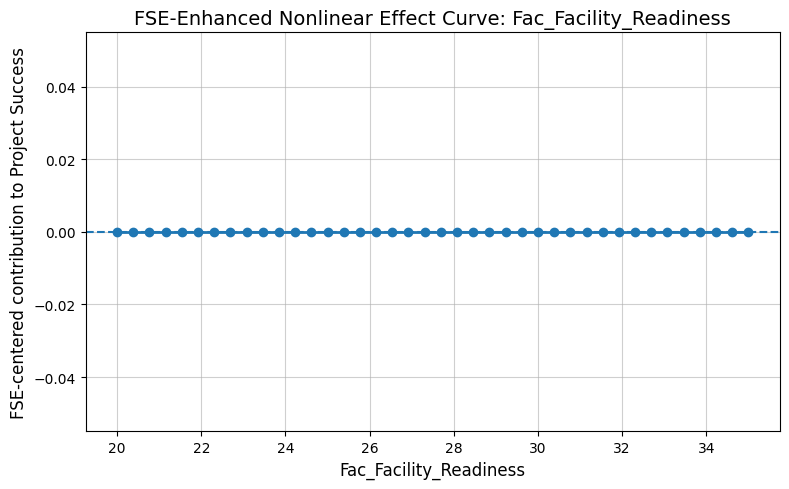

Saved: FSE_Nonlinear_Effect_Curve_Fac_Facility_Readiness.png


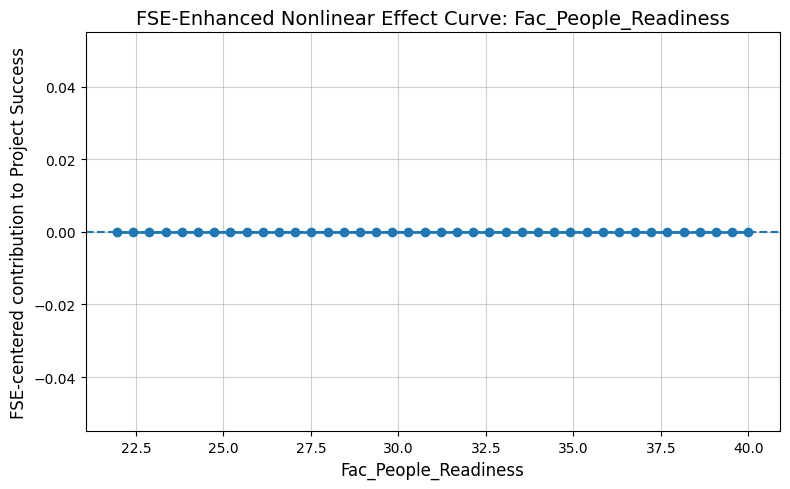

Saved: FSE_Nonlinear_Effect_Curve_Fac_People_Readiness.png


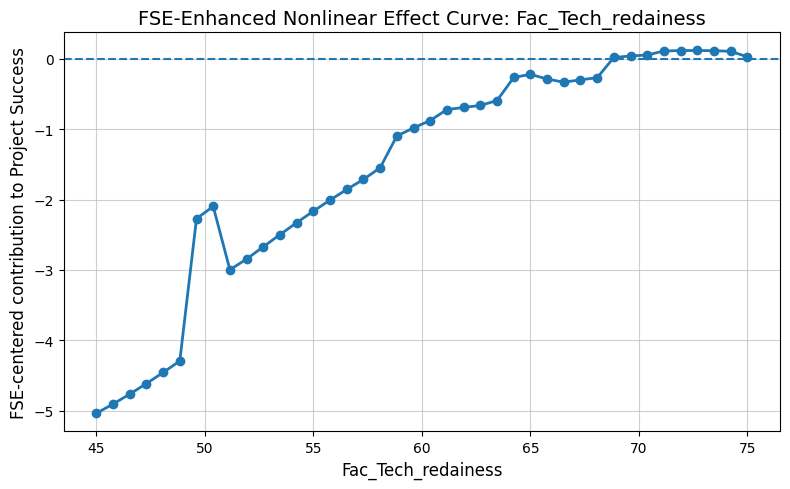

Saved: FSE_Nonlinear_Effect_Curve_Fac_Tech_redainess.png


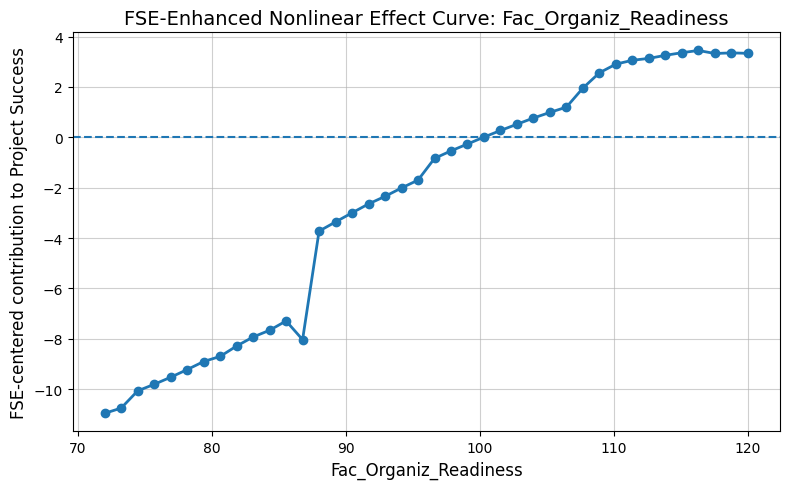

Saved: FSE_Nonlinear_Effect_Curve_Fac_Organiz_Readiness.png


,Feature,Importance,Importance_SD
3,Fac_Organiz_Readiness,3.398171,0.191594
2,Fac_Tech_redainess,0.729641,0.091914
1,Fac_People_Readiness,0.000000,0.000000
0,Fac_Facility_Readiness,0.000000,0.000000


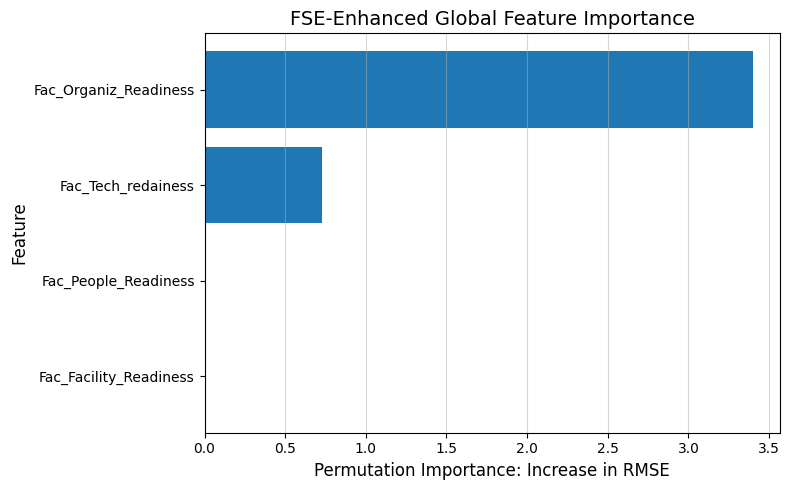

Saved: FSE_Enhanced_Global_Feature_Importance.png
Using existing fitted fse_full model.


,Feature,Importance,Importance_SD
3,Fac_Organiz_Readiness,3.584866,0.176707
2,Fac_Tech_redainess,0.323129,0.043304
8,Organization_type,0.079222,0.030201
6,Job,0.062952,0.027461
5,Airport,0.055557,0.026671
0,Fac_Facility_Readiness,0.000000,0.000000
1,Fac_People_Readiness,0.000000,0.000000
4,Gender,0.000000,0.000000
7,Organizational_tenure,0.000000,0.000000
9,Airport_projects,0.000000,0.000000


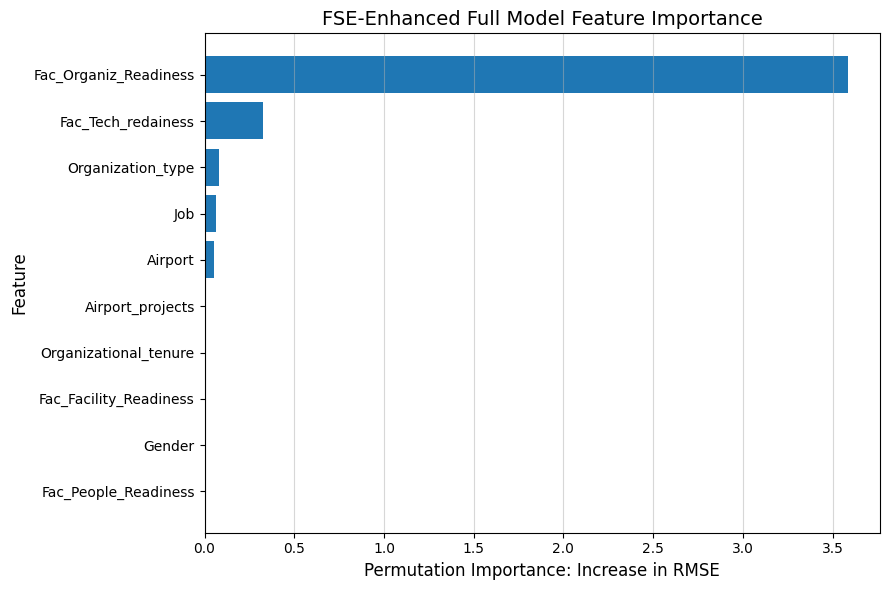

Saved: FSE_Enhanced_Full_Model_Feature_Importance.png


In [ ]:
# ============================================================
# FSE-Enhanced plots:
# 1. Centered partial dependence curves
# 2. Global permutation feature importance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance


# ============================================================
# 1. Make sure FSE main model is fitted
# ============================================================

X_main = df_clean[main_predictors].copy()
y_main = df_clean[target].astype(float).copy()

# If fse_main is not already fitted, fit it
try:
    fse_main
    print("Using existing fitted fse_main model.")
except NameError:
    print("Fitting FSE-Enhanced main model...")
    fse_main = build_fse_enhanced_model(X_main, y_main)
    fse_main.fit(X_main, y_main)


# ============================================================
# 2. Custom centered partial dependence function
# ============================================================

def compute_centered_pdp(model, X_data, feature, grid_points=40):
    """
    Computes centered partial dependence for one feature.
    This gives an FSE-style nonlinear effect curve.

    y-axis = average predicted project success at each feature value
             minus the overall mean prediction.
    """

    X_temp = X_data.copy()

    feature_values = X_temp[feature].dropna().values

    # Use percentile range to avoid extreme outlier effects
    low = np.percentile(feature_values, 1)
    high = np.percentile(feature_values, 99)

    grid = np.linspace(low, high, grid_points)

    pdp_values = []

    for value in grid:
        X_modified = X_temp.copy()
        X_modified[feature] = value

        preds = model.predict(X_modified)
        pdp_values.append(np.mean(preds))

    pdp_values = np.array(pdp_values)

    # Center the curve like EBM contribution plots
    baseline = np.mean(model.predict(X_temp))
    centered_pdp = pdp_values - baseline

    return grid, centered_pdp


# ============================================================
# 3. Plot FSE nonlinear effect curves
# ============================================================

for feature in main_predictors:

    grid, centered_effect = compute_centered_pdp(
        model=fse_main,
        X_data=X_main,
        feature=feature,
        grid_points=40
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        grid,
        centered_effect,
        marker="o",
        linewidth=2
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel(feature, fontsize=12)
    plt.ylabel("FSE-centered contribution to Project Success", fontsize=12)
    plt.title(f"FSE-Enhanced Nonlinear Effect Curve: {feature}", fontsize=14)

    plt.grid(True, linestyle="-", alpha=0.6)
    plt.tight_layout()

    filename = f"FSE_Nonlinear_Effect_Curve_{feature}.png"
    plt.savefig(filename, dpi=600, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)


# ============================================================
# 4. Global permutation feature importance for main FSE model
# ============================================================

perm_main = permutation_importance(
    fse_main,
    X_main,
    y_main,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

fse_main_importance_df = pd.DataFrame({
    "Feature": X_main.columns,
    "Importance": perm_main.importances_mean,
    "Importance_SD": perm_main.importances_std
}).sort_values("Importance", ascending=False)

display(fse_main_importance_df)


# ============================================================
# 5. Plot FSE global feature importance
# ============================================================

importance_plot_df = fse_main_importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_plot_df["Feature"],
    importance_plot_df["Importance"]
)

plt.xlabel("Permutation Importance: Increase in RMSE", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("FSE-Enhanced Global Feature Importance", fontsize=14)

plt.grid(axis="x", linestyle="-", alpha=0.5)
plt.tight_layout()

plt.savefig(
    "FSE_Enhanced_Global_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: FSE_Enhanced_Global_Feature_Importance.png")


# ============================================================
# 6. Optional: full model with controls
# ============================================================

X_full = df_clean[features].copy()
y_full = df_clean[target].astype(float).copy()

try:
    fse_full
    print("Using existing fitted fse_full model.")
except NameError:
    print("Fitting FSE-Enhanced full model with controls...")
    fse_full = build_fse_enhanced_model(X_full, y_full)
    fse_full.fit(X_full, y_full)

perm_full = permutation_importance(
    fse_full,
    X_full,
    y_full,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

fse_full_importance_df = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": perm_full.importances_mean,
    "Importance_SD": perm_full.importances_std
}).sort_values("Importance", ascending=False)

display(fse_full_importance_df)


# Plot full model feature importance
full_importance_plot_df = fse_full_importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    full_importance_plot_df["Feature"],
    full_importance_plot_df["Importance"]
)

plt.xlabel("Permutation Importance: Increase in RMSE", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("FSE-Enhanced Full Model Feature Importance", fontsize=14)

plt.grid(axis="x", linestyle="-", alpha=0.5)
plt.tight_layout()

plt.savefig(
    "FSE_Enhanced_Full_Model_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: FSE_Enhanced_Full_Model_Feature_Importance.png")